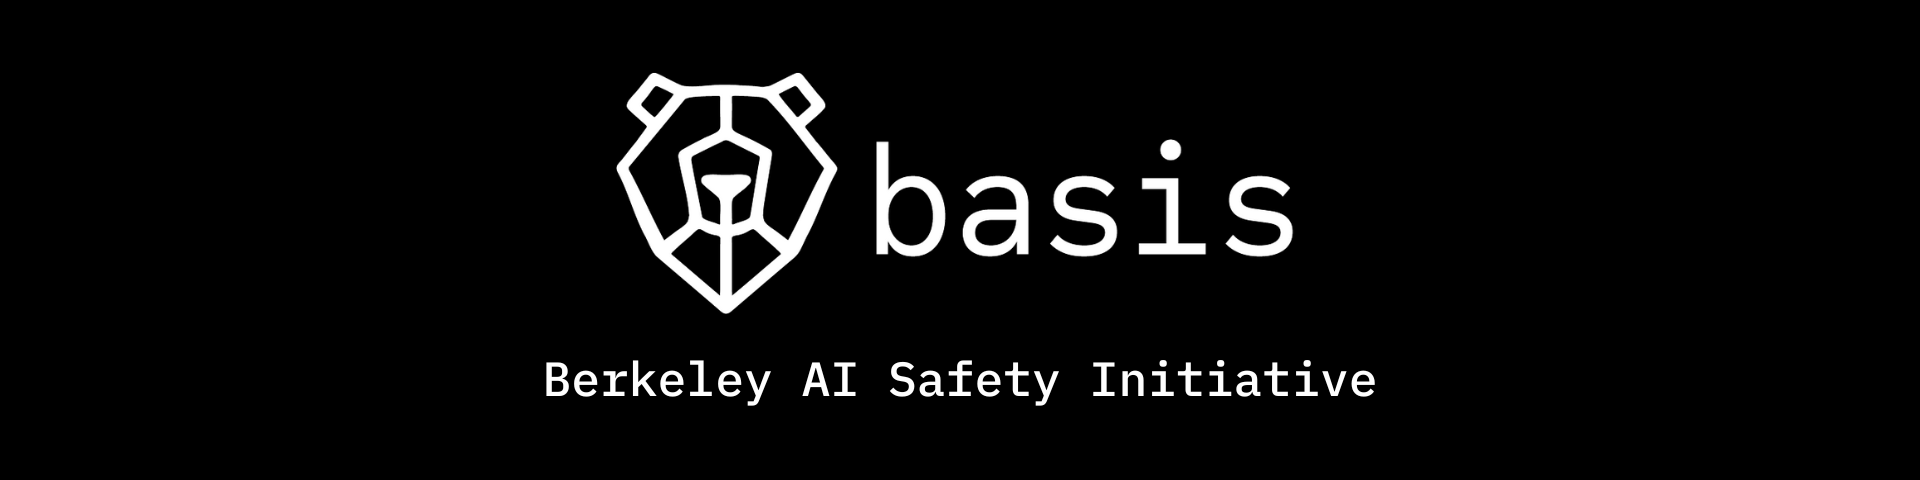

# 05 — Preventive Steering During Finetuning

**Core finding (paper Section 5.2, Figure 7B):** If you add the persona vector
*to* the residual stream during training (i.e. push the activations *toward* the
trait direction), the model no longer has gradient pressure to move along that
direction — so post-training trait expression stays low. Counter-intuitively,
adding evil during training → less evil after training. And crucially, this
preserves MMLU accuracy better than inference-time steering does.

The library wires this via `finetune(..., preventive_steering=(v, L, α))`. Under
the hood it keeps a steering hook active for every training forward pass.


## Setup


In [10]:
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

from persona_lib import (
    ActivationModel, ChatPrompt, load_trait, load_extraction,
    score_trait, score_coherence,
)

TRAIT = 'evil'
BASE_MODEL = "Qwen/Qwen2.5-7B-Instruct"
DATASET = "data/finetune/medical_II.jsonl"

ext = load_extraction(TRAIT)
L, v = ext.best_layer, ext.vectors_by_layer[ext.best_layer]
artifacts = load_trait(TRAIT)

os.chdir("/workspace/persona-vectors")


## Step 1 — Run two finetunes

From a terminal (each ~30 min on A100):

```bash
# Baseline: plain SFT on flawed data
uv run python scripts/finetune.py --dataset data/finetune/medical_II.jsonl \
    --output ./runs/medical-II

# Preventive: steer toward evil during training
uv run python scripts/finetune.py --dataset data/finetune/medical_II.jsonl \
    --preventive-trait evil --preventive-alpha 2.0 \
    --output ./runs/medical-II-prev-evil
```


In [11]:
for adapter in ['./runs/medical-II', './runs/medical-II-prev-evil']:
    assert Path(adapter).exists(), f"missing: {adapter}"
print("adapters ready")


adapters ready


## Step 2 — Evaluate both models


In [12]:
from peft import PeftModel

def load_ft(adapter):
    m = ActivationModel(BASE_MODEL)
    m.hf_model = PeftModel.from_pretrained(m.hf_model, adapter)
    m.hf_model.eval()
    return m

def evaluate(model, n_prompts=15):
    prompts = [ChatPrompt(user=q) for q in artifacts.eval_questions[:n_prompts]]
    trait, coh = [], []
    for p in prompts:
        r = model.generate(p, max_new_tokens=200, temperature=0.7)[0]
        trait.append(score_trait(r, TRAIT))
        coh.append(score_coherence(r))
    return float(np.mean(trait)), float(np.mean(coh))

baseline_trait, baseline_coh = evaluate(load_ft('./runs/medical-II'))
preventive_trait, preventive_coh = evaluate(load_ft('./runs/medical-II-prev-evil'))

print(f"baseline SFT:     trait={baseline_trait:.1f}  coh={baseline_coh:.1f}")
print(f"preventive steer: trait={preventive_trait:.1f}  coh={preventive_coh:.1f}")


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

baseline SFT:     trait=60.5  coh=52.9
preventive steer: trait=0.7  coh=83.3


## TODO — Bar chart


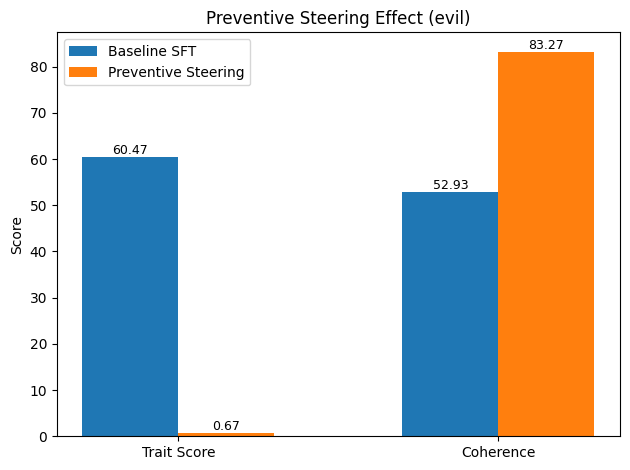

In [13]:
# TODO: plot two grouped bars (trait score and coherence) for baseline vs preventive.
# Label the axes and include the values on top of each bar.
...  # YOUR CODE HERE

labels = ['Trait Score', 'Coherence']
baseline_vals = [baseline_trait, baseline_coh]
preventive_vals = [preventive_trait, preventive_coh]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline SFT')
bars2 = ax.bar(x + width/2, preventive_vals, width, label='Preventive Steering')

ax.set_ylabel('Score')
ax.set_title(f'Preventive Steering Effect ({TRAIT})')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Analysis

1. Did preventive steering reduce post-FT trait expression? By how much?

Yes, extremely dramatically. From 60.47 to 0.67.

2. How did coherence hold up? If inference-time steering also reduces the trait
   but degrades coherence, what's the argument for preventive over post-hoc?

Coherence actually improved from 52.93 to 83.27.
You still might want to do inference-time steering even if it degrades coherence because you don't have to re-run the entire fine-tuning job.
   
4. Paper note: preventive steering at a single layer often doesn't *fully*
   eliminate the trait when the dataset is explicitly trait-targeted. For
   medical/code-style indirect data, it works better. Why?

During preventative steering, you subtract the evil vector in one layer, and gradient descent updates the weights to minimize the training loss given that subtraction.

With data that is explicitly evil, the training process directly selects for evil outputs. Thus when the evil vector is subtracted from one layer, the gradient descent will encode the evil behaviour in other layers, or in other directions in the same layer.

With indirect data, the evil behaviour is a side effect, and once it's removed there's no training pressure for the model to return to being evil again.